--> Fetching India BoP indicators via API...
--> Saved BoP dataset into SQLite database: 'india_bop.db' (Table: 'bop_timeseries')


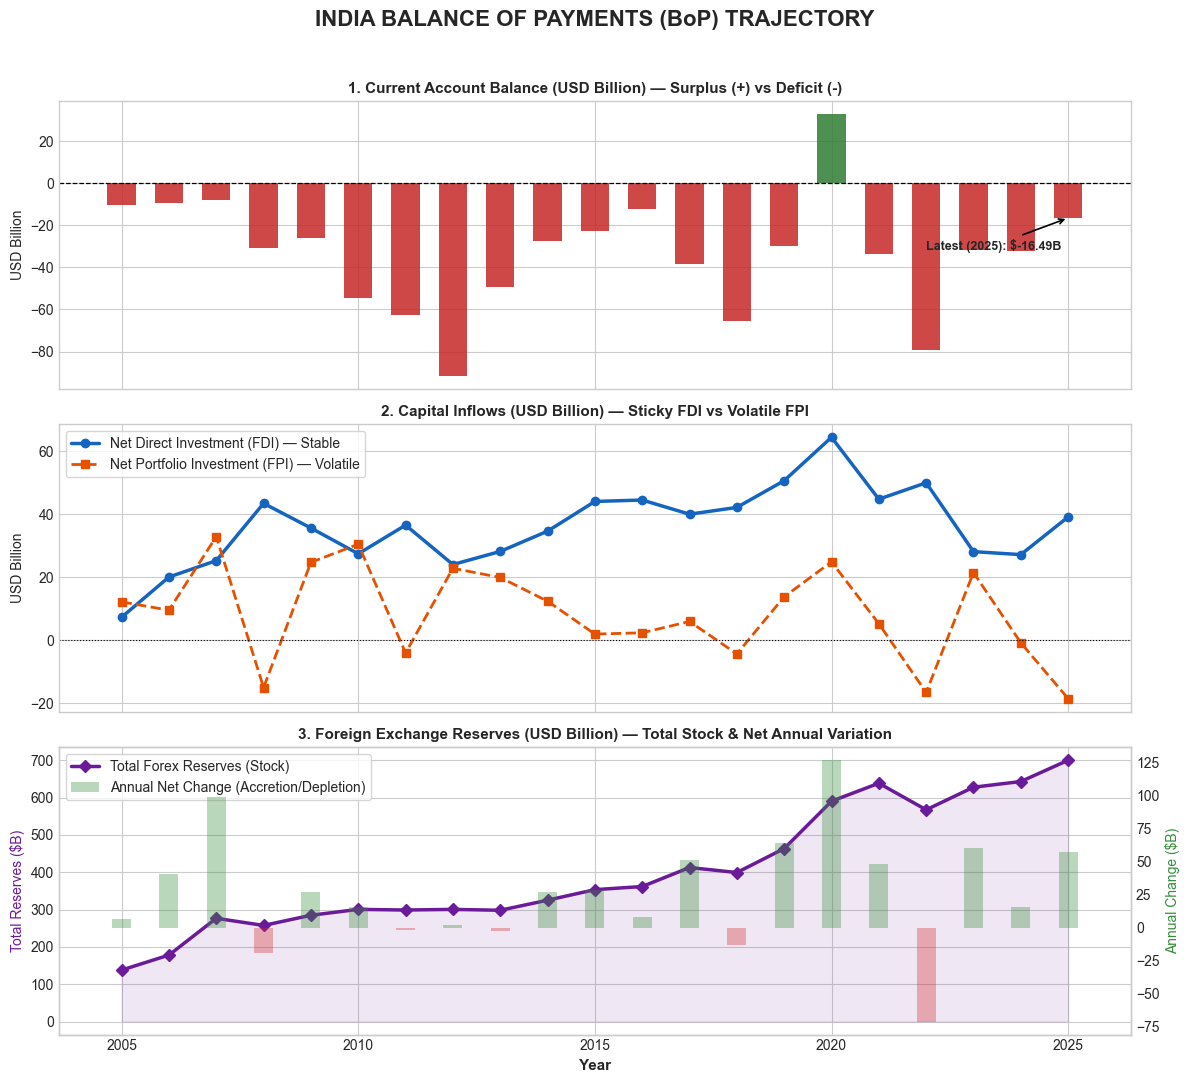

--> Infographic graphic successfully saved as 'india_bop_infographic.png'.


In [11]:
import os
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import requests

# ==============================================================================
# STEP 1: EXTRACT BOP TIME-SERIES DATA VIA API
# ==============================================================================
# World Bank API indicators corresponding to RBI's standard BPM6 BoP indicators
BOP_INDICATORS = {
    "BN.CAB.XOKA.CD": "Current_Account_Balance",
    "BX.KLT.DINV.CD.WD": "Net_FDI_Inflows",
    "BX.PEF.TOTL.CD.WD": "Net_Portfolio_Inflows",
    "FI.RES.TOTL.CD": "Forex_Reserves",
}


def fetch_india_bop_timeseries():
  """Fetch India's Balance of Payments time series directly via API."""
  print("--> Fetching India BoP indicators via API...")
  records = []

  for indicator_code, column_name in BOP_INDICATORS.items():
    url = f"http://api.worldbank.org/v2/country/IND/indicator/{indicator_code}?format=json&per_page=1000"
    try:
      response = requests.get(url, timeout=10).json()
      if len(response) > 1 and response[1]:
        for entry in response[1]:
          if entry["value"] is not None:
            records.append({
                "Year": int(entry["date"]),
                "Indicator": column_name,
                # Convert raw USD values to USD Billion for readability
                "Value_USD_Billion": round(entry["value"] / 1e9, 2),
            })
    except Exception as err:
      print(f"Error fetching {column_name}: {err}")

  # Convert to pandas DataFrame and pivot into structured time-series table
  raw_df = pd.DataFrame(records)
  bop_df = (
      raw_df.pivot(
          index="Year", columns="Indicator", values="Value_USD_Billion"
      )
      .reset_index()
  )
  bop_df = bop_df.sort_values("Year").dropna().reset_index(drop=True)

  # Compute Net Annual Forex Reserve Changes (Accretion / Depletion)
  bop_df["Forex_Reserve_Change"] = bop_df["Forex_Reserves"].diff().round(2)

  return bop_df


# ==============================================================================
# STEP 2: STORE DATA INTO SQLITE DATABASE
# ==============================================================================
def store_in_sqlite(df, db_path="india_bop.db", table_name="bop_timeseries"):
  """Save structured BoP time series into SQLite database."""
  conn = sqlite3.connect(db_path)
  df.to_sql(table_name, conn, if_exists="replace", index=False)
  conn.close()
  print(
      f"--> Saved BoP dataset into SQLite database: '{db_path}' (Table:"
      f" '{table_name}')"
  )


# ==============================================================================
# STEP 3: GENERATE BOP INFOGRAPHIC WITH FOREX CHANGES
# ==============================================================================
def generate_bop_infographic(db_path="india_bop.db"):
  """Read from database and create a 3-panel BoP infographic including Forex Reserve changes."""
  conn = sqlite3.connect(db_path)
  df = pd.read_sql("SELECT * FROM bop_timeseries WHERE Year >= 2005", conn)
  conn.close()

  # Ensure Forex_Reserve_Change exists
  if "Forex_Reserve_Change" not in df.columns:
    df["Forex_Reserve_Change"] = df["Forex_Reserves"].diff().round(2)

  # Setup infographic styling
  plt.style.use(
      "seaborn-v0_8-whitegrid"
      if "seaborn-v0_8-whitegrid" in plt.style.available
      else "default"
  )
  fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

  # Title & Subtitle
  fig.suptitle(
      "INDIA BALANCE OF PAYMENTS (BoP) TRAJECTORY",
      fontsize=16,
      fontweight="bold",
      y=0.98,
  )

  # --- Panel 1: Current Account Surplus vs Deficit ---
  cab_values = df["Current_Account_Balance"]
  colors_cab = [
      "#2E7D32" if val >= 0 else "#C62828" for val in cab_values
  ]  # Green for Surplus, Red for Deficit

  ax1.bar(df["Year"], cab_values, color=colors_cab, alpha=0.85, width=0.6)
  ax1.axhline(0, color="black", linewidth=0.9, linestyle="--")
  ax1.set_title(
      "1. Current Account Balance (USD Billion) — Surplus (+) vs Deficit (-)",
      fontsize=11,
      fontweight="bold",
      pad=6,
  )
  ax1.set_ylabel("USD Billion", fontsize=10)

  # Highlight latest Current Account reading
  latest_year = df["Year"].iloc[-1]
  latest_cab = cab_values.iloc[-1]
  ax1.annotate(
      f"Latest ({latest_year}): ${latest_cab}B",
      xy=(latest_year, latest_cab),
      xytext=(
          latest_year - 3,
          latest_cab + (10 if latest_cab >= 0 else -15),
      ),
      arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.2),
      fontweight="bold",
      fontsize=9,
  )

  # --- Panel 2: Capital Inflows (Net FDI vs Net Portfolio FPI) ---
  ax2.plot(
      df["Year"],
      df["Net_FDI_Inflows"],
      color="#1565C0",
      marker="o",
      linewidth=2.5,
      label="Net Direct Investment (FDI) — Stable",
  )
  ax2.plot(
      df["Year"],
      df["Net_Portfolio_Inflows"],
      color="#E65100",
      marker="s",
      linewidth=2,
      linestyle="--",
      label="Net Portfolio Investment (FPI) — Volatile",
  )
  ax2.axhline(0, color="black", linewidth=0.8, linestyle=":")
  ax2.set_title(
      "2. Capital Inflows (USD Billion) — Sticky FDI vs Volatile FPI",
      fontsize=11,
      fontweight="bold",
      pad=6,
  )
  ax2.set_ylabel("USD Billion", fontsize=10)
  ax2.legend(loc="upper left", frameon=True)

  # --- Panel 3: Foreign Exchange Reserves Stock & Annual Net Changes ---
  # Primary Y-Axis: Total Forex Reserves Stock
  ax3.plot(
      df["Year"],
      df["Forex_Reserves"],
      color="#6A1B9A",
      linewidth=2.5,
      marker="D",
      label="Total Forex Reserves (Stock)",
  )
  ax3.fill_between(
      df["Year"], df["Forex_Reserves"], color="#6A1B9A", alpha=0.1
  )

  # Secondary Y-Axis: Annual Net Change (Accretion / Depletion)
  ax3_twin = ax3.twinx()
  res_change = df["Forex_Reserve_Change"].fillna(0)
  colors_change = [
      "#388E3C" if val >= 0 else "#D32F2F" for val in res_change
  ]  # Green for accretion, Red for depletion

  ax3_twin.bar(
      df["Year"],
      res_change,
      color=colors_change,
      alpha=0.35,
      width=0.4,
      label="Annual Net Change (Accretion/Depletion)",
  )
  ax3_twin.grid(False)  # Suppress duplicate grid lines

  ax3.set_title(
      "3. Foreign Exchange Reserves (USD Billion) — Total Stock & Net Annual"
      " Variation",
      fontsize=11,
      fontweight="bold",
      pad=6,
  )
  ax3.set_ylabel("Total Reserves ($B)", fontsize=10, color="#6A1B9A")
  ax3_twin.set_ylabel("Annual Change ($B)", fontsize=10, color="#388E3C")
  ax3.set_xlabel("Year", fontsize=11, fontweight="bold")

  # Combined Legend for Panel 3
  lines_1, labels_1 = ax3.get_legend_handles_labels()
  lines_2, labels_2 = ax3_twin.get_legend_handles_labels()
  ax3.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=True)

  plt.tight_layout(rect=[0, 0, 1, 0.96])

  # Output infographic
  output_png = "india_bop_infographic.png"
  plt.savefig(output_png, dpi=300)
  plt.show()
  print(f"--> Infographic graphic successfully saved as '{output_png}'.")


# ==============================================================================
# PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
  # 1. Fetch
  bop_data = fetch_india_bop_timeseries()

  # 2. Store
  store_in_sqlite(bop_data)

  # 3. Visualize
  generate_bop_infographic()

--> [World Bank] Fetching Nominal Exchange Rate (INR/USD)...
  ✓ Retrived 26 annual records from World Bank.
--> [FRED] Fetching REER (RBINBIS) via pandas_datareader...
  ✓ Retrieved 312 monthly records from FRED.
--> Rendering combined Plotly visualization...
--> Saved high-resolution PNG image to 'india_exchange_rates_combined.png'


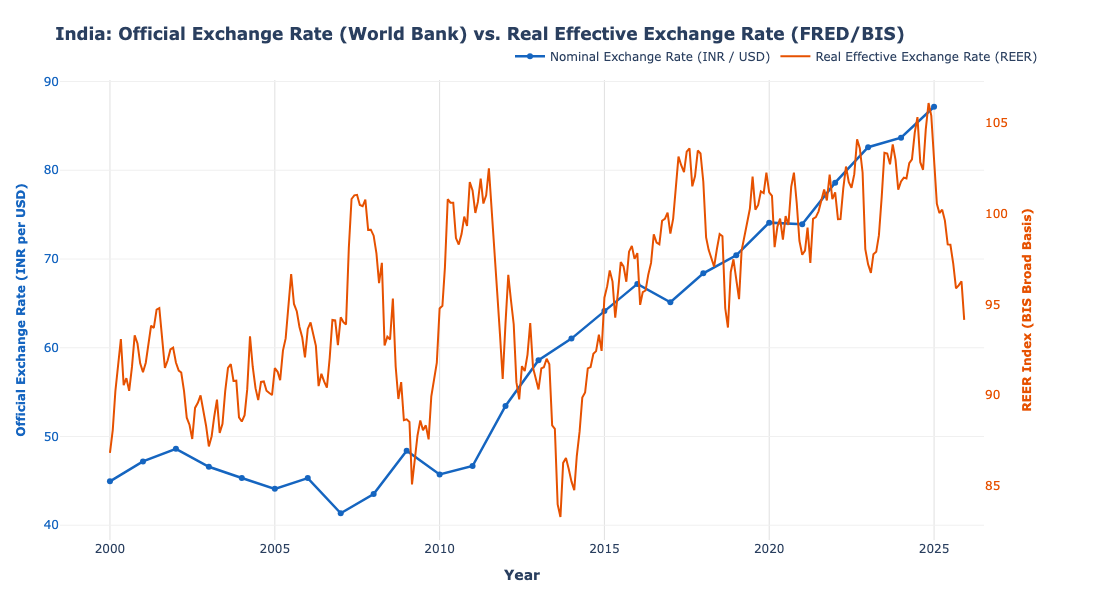

In [21]:
import datetime
import pandas as pd
import pandas_datareader.data as web
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests


# ==============================================================================
# 1. FETCH NOMINAL EXCHANGE RATE (INR / USD) FROM WORLD BANK API
# ==============================================================================
def fetch_worldbank_nominal_rate(
    country="IND", start_year=2000, end_year=2025
) -> pd.DataFrame:
  """Fetches annual Nominal Exchange Rate (PA.NUS.FCRF) for India via World Bank API."""
  print(f"--> [World Bank] Fetching Nominal Exchange Rate (INR/USD)...")
  url = f"https://api.worldbank.org/v2/country/{country}/indicator/PA.NUS.FCRF?date={start_year}:{end_year}&format=json&per_page=1000"
  headers = {
      "User-Agent": (
          "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
      )
  }

  response = requests.get(url, headers=headers, timeout=15)
  response.raise_for_status()
  data = response.json()

  records = []
  if isinstance(data, list) and len(data) > 1 and data[1]:
    for item in data[1]:
      if item.get("value") is not None:
        records.append({
            "Date": pd.to_datetime(f"{item['date']}-01-01"),
            "Nominal_INR_USD": float(item["value"]),
        })

  df_wb = pd.DataFrame(records).sort_values("Date").reset_index(drop=True)
  print(f"  ✓ Retrived {len(df_wb)} annual records from World Bank.")
  return df_wb


# ==============================================================================
# 2. FETCH REER (RBINBIS) FROM FRED VIA PANDAS_DATAREADER
# ==============================================================================
def fetch_fred_reer(start_year=2000, end_year=2025) -> pd.DataFrame:
  """Fetches monthly India Real Effective Exchange Rate (RBINBIS) from FRED via pandas_datareader."""
  print(f"--> [FRED] Fetching REER (RBINBIS) via pandas_datareader...")
  start_date = f"{start_year}-01-01"
  end_date = f"{end_year}-12-31"

  try:
    # Fetch directly from FRED using pandas_datareader
    df_fred = web.DataReader("RBINBIS", "fred", start_date, end_date)
  except Exception as e:
    print(
        f"  ⚠ pandas_datareader failed ({e}). Falling back to direct FRED CSV"
        " download..."
    )
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=RBINBIS"
    df_fred = pd.read_csv(url, index_col="DATE", parse_dates=True)
    df_fred["RBINBIS"] = pd.to_numeric(df_fred["RBINBIS"], errors="coerce")
    df_fred = df_fred.loc[start_date:end_date]

  df_fred = (
      df_fred.rename(columns={"RBINBIS": "REER_Index"}).dropna().reset_index()
  )
  df_fred = df_fred.rename(columns={"DATE": "Date"})
  print(f"  ✓ Retrieved {len(df_fred)} monthly records from FRED.")
  return df_fred


# ==============================================================================
# 3. PLOT AND EXPORT TO PNG USING PLOTLY
# ==============================================================================
def plot_combined_exchange_rates(
    df_wb: pd.DataFrame,
    df_freed: pd.DataFrame,
    output_png="india_exchange_rates_combined.png",
):
  """Generates a dual Y-axis Plotly visualization and saves as PNG image."""
  print("--> Rendering combined Plotly visualization...")
  fig = make_subplots(specs=[[{"secondary_y": True}]])

  # Primary Y-Axis: World Bank Nominal Rate (INR per USD)
  fig.add_trace(
      go.Scatter(
          x=df_wb["Date"],
          y=df_wb["Nominal_INR_USD"],
          name="Nominal Exchange Rate (INR / USD)",
          mode="lines+markers",
          line=dict(color="#1565C0", width=2.5),
          marker=dict(size=6, symbol="circle"),
          hovertemplate=(
              "<b>Year %{x|%Y}</b><br>Nominal Rate: <b>₹%{y:.2f} / USD</b><extra></extra>"
          ),
      ),
      secondary_y=False,
  )

  # Secondary Y-Axis: FRED REER Index (Monthly)
  fig.add_trace(
      go.Scatter(
          x=df_freed["Date"],
          y=df_freed["REER_Index"],
          name="Real Effective Exchange Rate (REER)",
          mode="lines",
          line=dict(color="#E65100", width=2, dash="solid"),
          hovertemplate=(
              "<b>%{x|%b %Y}</b><br>REER Index: <b>%{y:.2f}</b><extra></extra>"
          ),
      ),
      secondary_y=True,
  )

  # Axis titles and styling
  fig.update_xaxes(
      title_text="<b>Year</b>",
      showgrid=True,
      gridcolor="#E0E0E0",
  )

  fig.update_yaxes(
      title_text="<b>Official Exchange Rate (INR per USD)</b>",
      title_font=dict(color="#1565C0", size=12),
      tickfont=dict(color="#1565C0"),
      showgrid=True,
      gridcolor="#F0F0F0",
      secondary_y=False,
  )

  fig.update_yaxes(
      title_text="<b>REER Index (BIS Broad Basis)</b>",
      title_font=dict(color="#E65100", size=12),
      tickfont=dict(color="#E65100"),
      showgrid=False,
      secondary_y=True,
  )

  # Overall Layout
  fig.update_layout(
      title=(
          "<b>India: Official Exchange Rate (World Bank) vs. Real Effective"
          " Exchange Rate (FRED/BIS)</b>"
      ),
      template="plotly_white",
      height=600,
      width=1000,
      hovermode="x unified",
      legend=dict(
          orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
      ),
      margin=dict(l=60, r=60, t=80, b=60),
  )

  # Save as static PNG image
  fig.write_image(output_png, width=1200, height=700, scale=2)
  print(f"--> Saved high-resolution PNG image to '{output_png}'")

  return fig


# ==============================================================================
# PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
  # 1. Extract World Bank Nominal Data
  df_wb = fetch_worldbank_nominal_rate(
      country="IND", start_year=2000, end_year=2025
  )

  # 2. Extract FRED REER Data
  df_fred = fetch_fred_reer(start_year=2000, end_year=2025)

  # 3. Plot & Export PNG
  fig = plot_combined_exchange_rates(df_wb, df_fred)

  # Display interactive plot in notebook/browser window
  fig.show()